In [1]:
# --------------------------------
# Imports & Path Setup
# --------------------------------

%reload_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

from src.compression.fourier import FourierCompressor
from src.compression.wavelet import WaveletCompressor

from src.utils.inference import restore_image
from src.utils.plot import make_output_name, plot_restoration_comparation_between_models, plot_restoration

from src.models.restormer import RestormerModel

In [2]:
# --------------------------------
# Paths
# --------------------------------

INFERENCE_DIR = Path("data/inference_tests")
ORIGINAL_IMG = Path("data/inference_tests/original.png")

MODEL_ALL_DATA = Path("checkpoints/best_model_restormer_20260327_122913.pth")
MODEL_FOURIER_ONLY = Path(
    "checkpoints/best_model_restormer_fourier_20260328_103041.pth"
)
MODEL_WAVELET_ONLY = Path(
    "checkpoints/best_model_restormer_wavelet_20260328_110824.pth"
)

MODEL_SAVE_LABELS = {
    MODEL_ALL_DATA: "all_data",
    MODEL_FOURIER_ONLY: "fourier_only",
    MODEL_WAVELET_ONLY: "wavelet_only",
}

MODEL_DISPLAY_LABELS = ["All data", "Fourier only", "Wavelet only"]

In [3]:
# --------------------------------
# Fourier 0.25
# --------------------------------

fourier = FourierCompressor(keep_fraction=0.25)
fourier.compress(ORIGINAL_IMG, INFERENCE_DIR);

# --------------------------------
# Wavelet haar, lvl 1, 20.0
# --------------------------------

wavelet = WaveletCompressor(wavelet="haar", level=1, threshold=20.0, keep_ll_only=True)
wavelet.compress(ORIGINAL_IMG, INFERENCE_DIR);

In [4]:
# --------------------------------
# Restoring
# --------------------------------
    
compressed_fourier = INFERENCE_DIR / "original_fourier_25.png"
compressed_wavelet = INFERENCE_DIR / "original_wavelet_haar_1_20_ll_only.png"

checkpoints = [MODEL_ALL_DATA, MODEL_FOURIER_ONLY, MODEL_WAVELET_ONLY]

for compressed in [compressed_fourier, compressed_wavelet]:
    for checkpoint_path in checkpoints:
        model_instance = RestormerModel()
        restored = restore_image(
            compressed_path=str(compressed),
            checkpoint_path=str(checkpoint_path),
            model=model_instance,
            device="cpu",
        )
        out_name = make_output_name(compressed, checkpoint_path, model_instance.__class__.__name__, MODEL_SAVE_LABELS)
        restored.save(INFERENCE_DIR / out_name)
        print(f"Saved: {out_name}")

Saved: restored_RestormerModel_original_fourier_25_all_data.png
Saved: restored_RestormerModel_original_fourier_25_fourier_only.png
Saved: restored_RestormerModel_original_fourier_25_wavelet_only.png
Saved: restored_RestormerModel_original_wavelet_haar_1_20_ll_only_all_data.png
Saved: restored_RestormerModel_original_wavelet_haar_1_20_ll_only_fourier_only.png
Saved: restored_RestormerModel_original_wavelet_haar_1_20_ll_only_wavelet_only.png


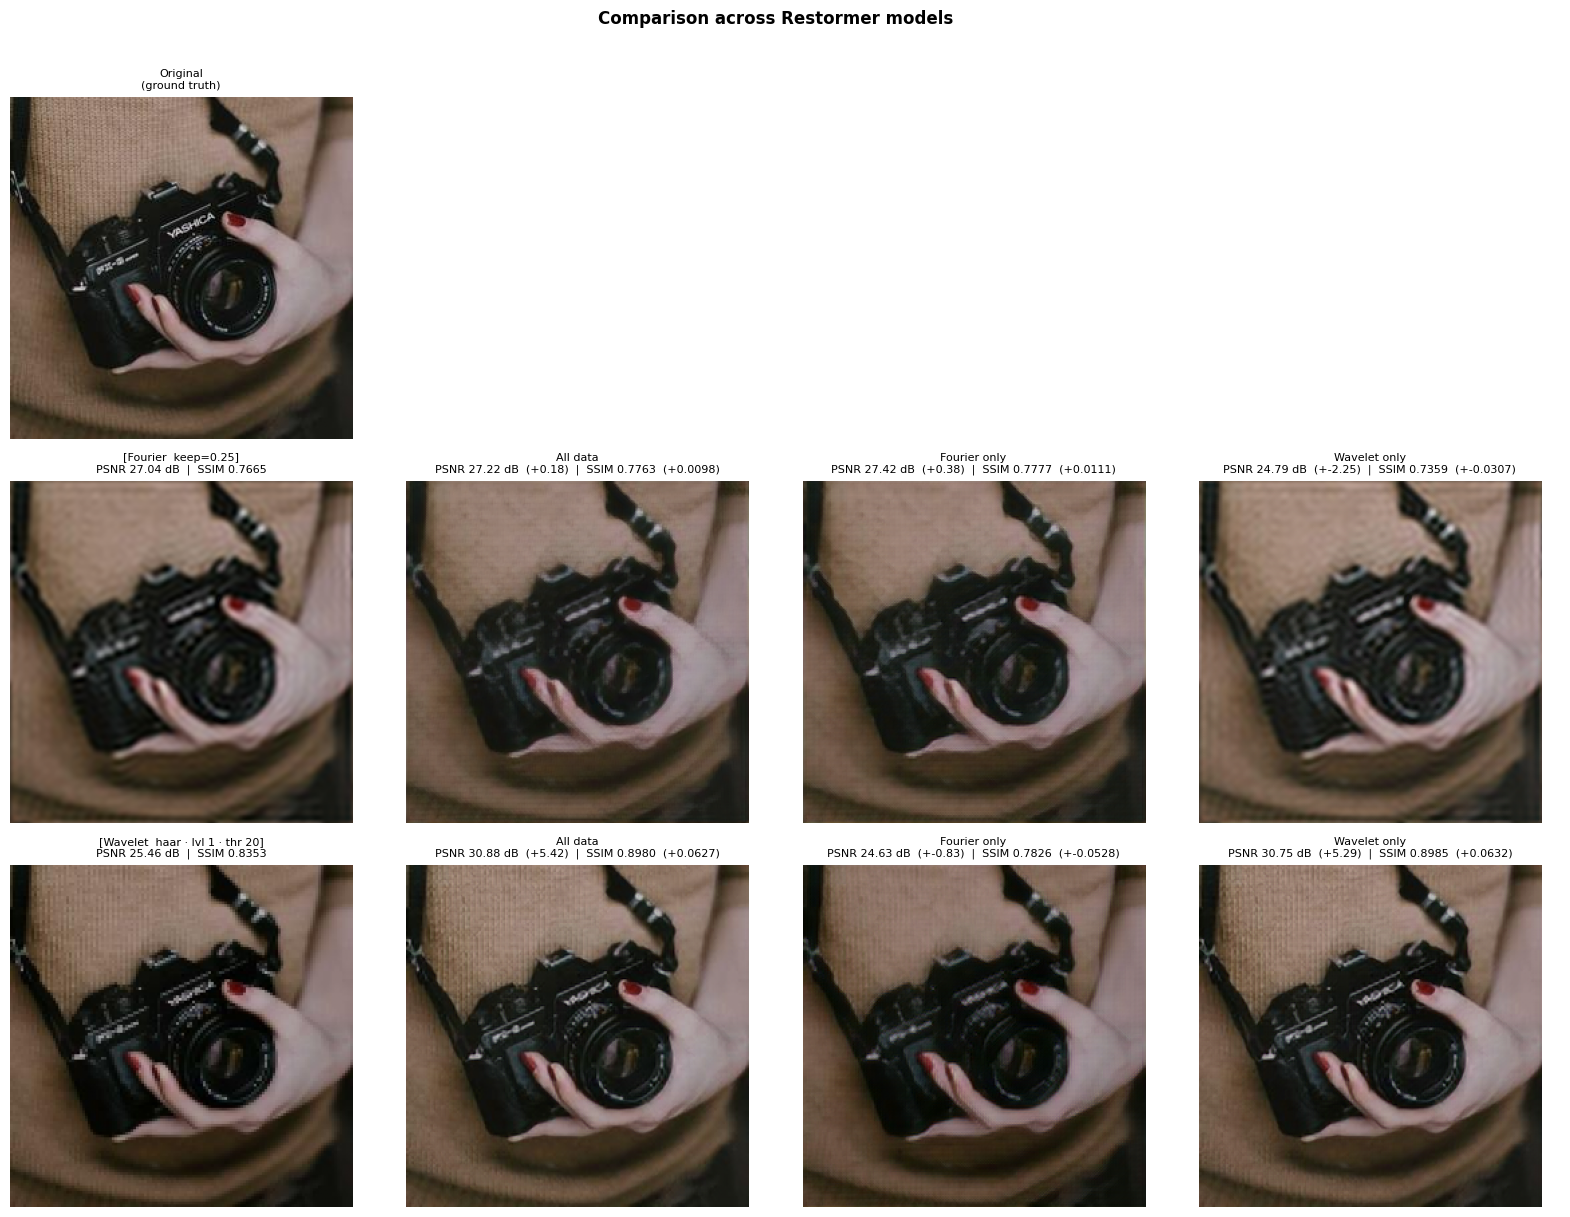

In [6]:
plot_restoration_comparation_between_models(
    title="Comparison across Restormer models",
    original_path=ORIGINAL_IMG,
    compressions=[
        {
            "compressed_path": compressed_fourier, 
            "label": "Fourier  keep=0.25"
        },
        {
            "compressed_path": compressed_wavelet,
            "label": "Wavelet  haar · lvl 1 · thr 20",
        },
    ],
    model_paths=[MODEL_ALL_DATA, MODEL_FOURIER_ONLY, MODEL_WAVELET_ONLY],
    model_display_labels=MODEL_DISPLAY_LABELS,
    model_save_labels=MODEL_SAVE_LABELS,
    model_type=model_instance.__class__.__name__,
)